In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/hr_clean.csv')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (1470, 39)


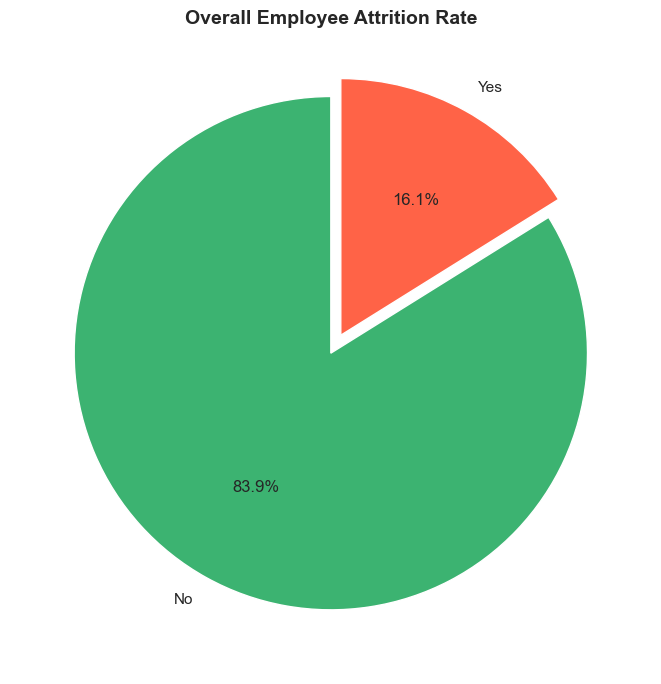

Chart saved!


In [4]:
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(7,7))
colors = ['mediumseagreen', 'tomato']
plt.pie(attrition_counts, 
        labels=attrition_counts.index, 
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=(0, 0.08))

plt.title('Overall Employee Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/screenshots/01_overall_attrition.png', dpi=150)
plt.show()
print("Chart saved!")

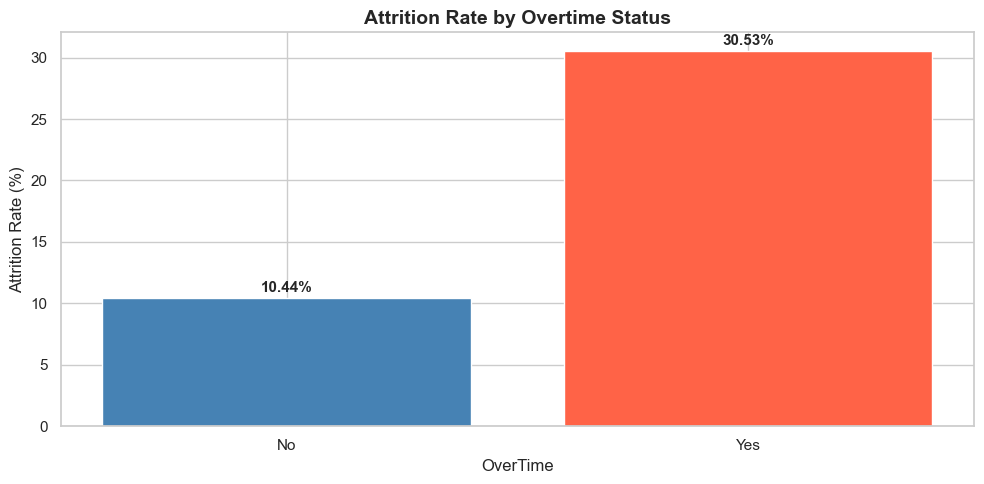

Chart saved!


In [5]:
overtime_attrition = df.groupby('OverTime')['Attrition_Flag'].mean() * 100
overtime_attrition = overtime_attrition.round(2)

plt.figure()
colors = ['steelblue', 'tomato']
bars = plt.bar(overtime_attrition.index, overtime_attrition.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height()}%', ha='center', fontsize=11, fontweight='bold')

plt.title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('OverTime')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/02_attrition_by_overtime.png', dpi=150)
plt.show()
print("Chart saved!")

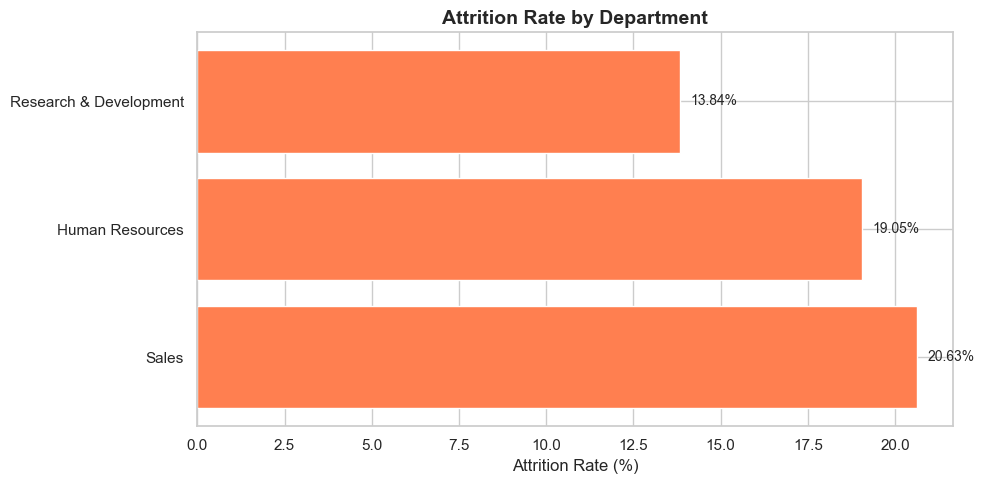

Chart saved!


In [6]:
dept_attrition = df.groupby('Department')['Attrition_Flag'].mean().sort_values(ascending=False) * 100
dept_attrition = dept_attrition.round(2)

plt.figure()
bars = plt.barh(dept_attrition.index, dept_attrition.values, color='coral')

for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width()}%', va='center', fontsize=10)

plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/03_attrition_by_department.png', dpi=150)
plt.show()
print("Chart saved!")

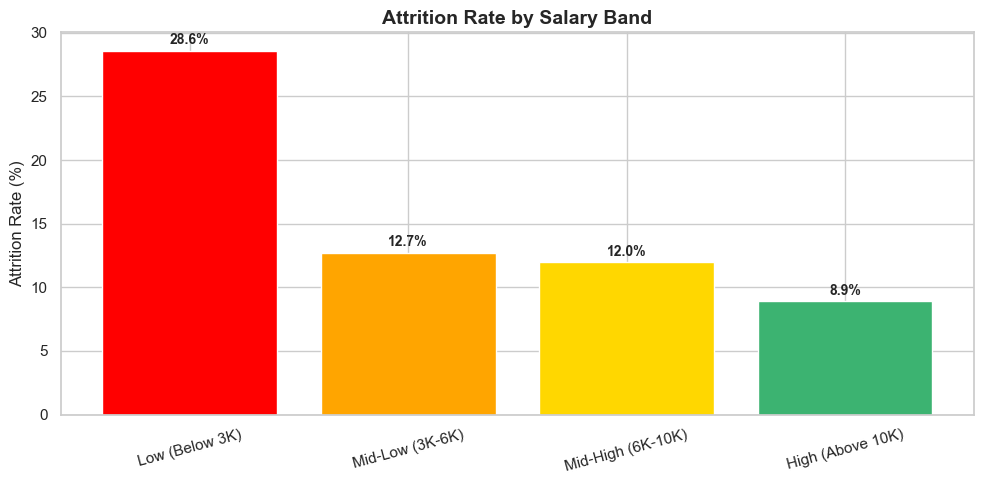

Chart saved!


In [7]:
salary_attrition = df.groupby('Salary_Band')['Attrition_Flag'].mean().round(4) * 100
salary_attrition = salary_attrition.reindex(['Low (Below 3K)', 'Mid-Low (3K-6K)', 'Mid-High (6K-10K)', 'High (Above 10K)'])

plt.figure()
colors = ['red', 'orange', 'gold', 'mediumseagreen']
bars = plt.bar(salary_attrition.index, salary_attrition.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Attrition Rate by Salary Band', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/04_attrition_by_salary.png', dpi=150)
plt.show()
print("Chart saved!")

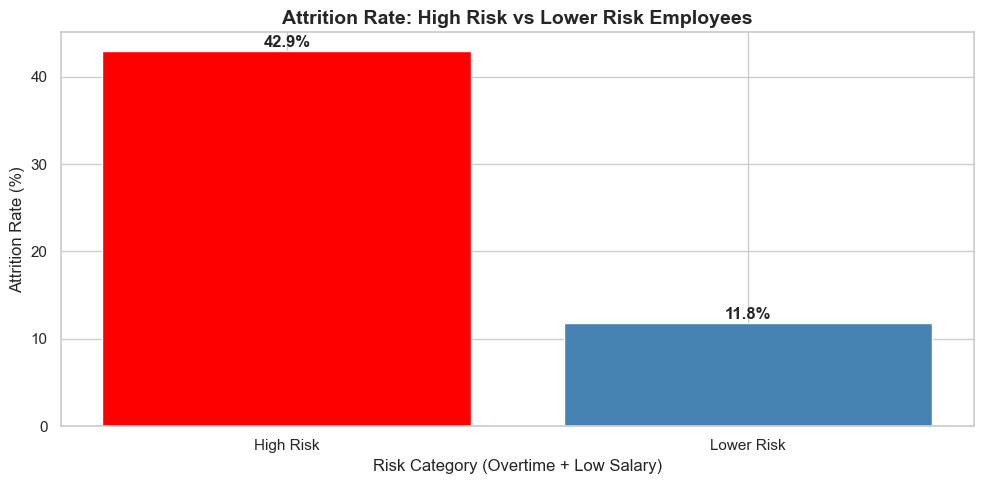

Chart saved!


In [8]:
risk_attrition = df.groupby('Risk_Category')['Attrition_Flag'].mean().round(4) * 100

plt.figure()
colors = ['red', 'steelblue']
bars = plt.bar(risk_attrition.index, risk_attrition.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Attrition Rate: High Risk vs Lower Risk Employees', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Risk Category (Overtime + Low Salary)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/05_risk_category_attrition.png', dpi=150)
plt.show()
print("Chart saved!")

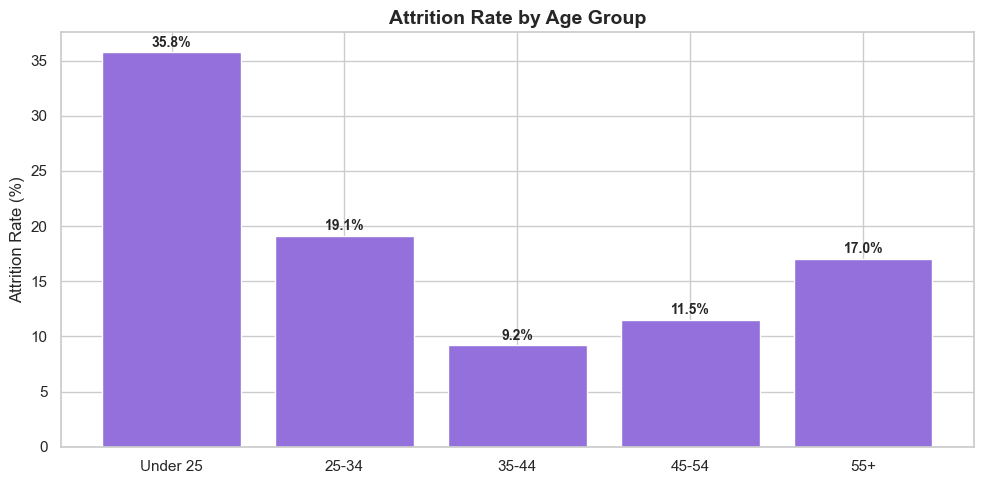

Chart saved!


In [9]:
age_attrition = df.groupby('Age_Group')['Attrition_Flag'].mean().round(4) * 100
age_attrition = age_attrition.reindex(['Under 25', '25-34', '35-44', '45-54', '55+'])

plt.figure()
bars = plt.bar(age_attrition.index, age_attrition.values, color='mediumpurple')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/06_attrition_by_age.png', dpi=150)
plt.show()
print("Chart saved!")

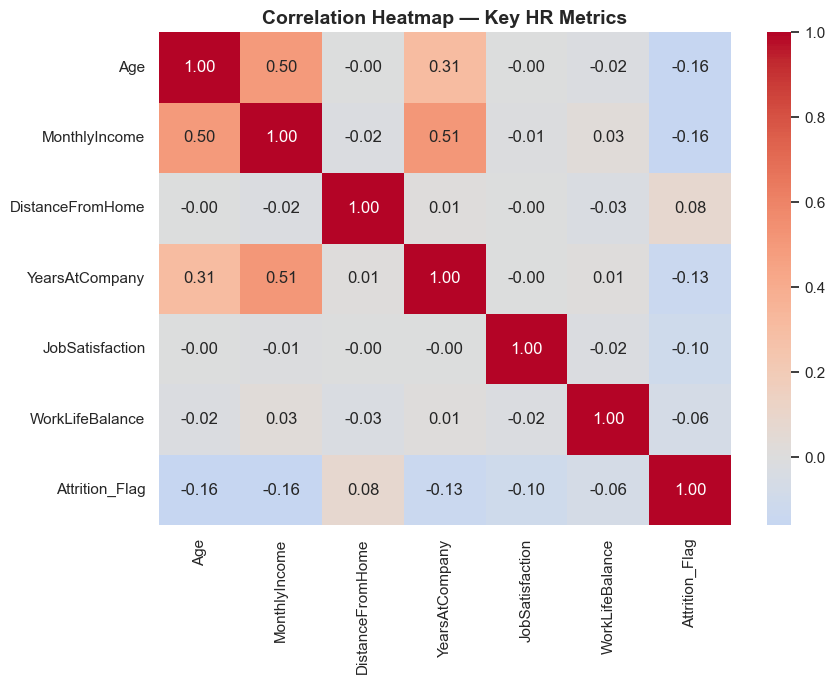

Chart saved!


In [10]:
numeric_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany', 
                 'JobSatisfaction', 'WorkLifeBalance', 'Attrition_Flag']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap — Key HR Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/07_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart saved!")